# LAB7


**Disclosure:**

> HAIL `LEVEL 3`: In this Laboratory, I use `Deepseek` to help me complete code faster, and use `Codex` to refine the discussion. I checked and adjusted the code/results during the process.


## Data Loading


MATLAB v7.3 `.mat` files need to be read by `h5py`. The following cell reads the MRI image and tumor mask, then shows the original image, mask, and red tumor boundary overlay.


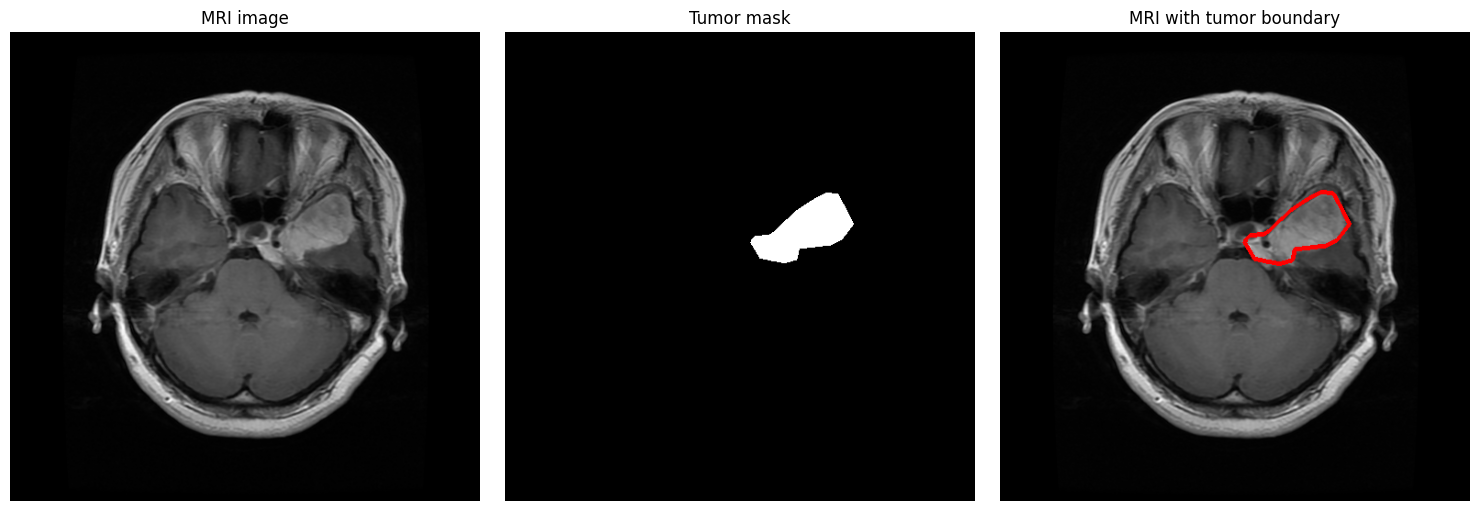

In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray
from skimage.morphology import dilation, disk
from skimage.segmentation import find_boundaries


def read_mri_image(
    mat_path: str | Path,
    boundary_width: int = 3,
) -> tuple[NDArray[np.integer], NDArray[np.bool_], NDArray[np.floating]]:
    """Read MRI image, tumor mask, and an MRI image with red tumor boundary."""
    mat_path = Path(mat_path)

    with h5py.File(mat_path, "r") as f:
        mri_image = np.array(f["cjdata/image"]).T
        tumor_mask = np.array(f["cjdata/tumorMask"]).T.astype(bool)

    image_min = mri_image.min()
    image_max = mri_image.max()
    normalized_image = (mri_image - image_min) / (image_max - image_min)
    image_with_tumor_boundary = np.dstack([normalized_image] * 3)

    tumor_boundary = find_boundaries(tumor_mask, mode="outer")
    tumor_boundary = dilation(tumor_boundary, footprint=disk(boundary_width))
    image_with_tumor_boundary[tumor_boundary] = [1.0, 0.0, 0.0]

    return mri_image, tumor_mask, image_with_tumor_boundary


def show_mri_image(
    mri_image: NDArray[np.integer],
    tumor_mask: NDArray[np.bool_],
    image_with_tumor_boundary: NDArray[np.floating],
) -> None:
    """Show MRI image, tumor mask, and MRI image with red tumor boundary."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(mri_image, cmap="gray")
    axes[0].set_title("MRI image")
    axes[0].axis("off")

    axes[1].imshow(tumor_mask, cmap="gray")
    axes[1].set_title("Tumor mask")
    axes[1].axis("off")

    axes[2].imshow(image_with_tumor_boundary)
    axes[2].set_title("MRI with tumor boundary")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()



# test the functions: read and show MRI image
data_dir = Path("data")
if not data_dir.exists():
    data_dir = Path("LAB_07/data")

mri_image, tumor_mask, image_with_tumor_boundary = read_mri_image(data_dir / "1.mat", boundary_width=2)
show_mri_image(mri_image, tumor_mask, image_with_tumor_boundary)


## Project 1 Shape Feature & Fourier Descriptors

### 1.1 Implement the Fourier Descriptors extraction

先实现傅里叶描述提取算法，其中 P 一定要是可以修改的参数。

In [2]:
# function: Fourier Descriptors extraction

# get the boundary from the tumor mask first
def extract_boundary_points(tumor_mask: NDArray[np.bool_]) -> NDArray[np.floating]:
    """Extract boundary pixels from a binary tumor mask and sort them by polar angle."""
    boundary_mask = find_boundaries(tumor_mask.astype(bool), mode="outer")
    rows, cols = np.nonzero(boundary_mask)
    boundary_points = np.column_stack((cols, rows)).astype(float)
    if boundary_points.shape[0] < 3:
        raise ValueError("The tumor mask does not contain enough boundary points.")

    center = boundary_points.mean(axis=0)
    angles = np.arctan2(boundary_points[:, 1] - center[1], boundary_points[:, 0] - center[0])
    order = np.argsort(angles)
    return boundary_points[order]

# all points on boundary -> resampled boundary points sorted by polar angle
# not need to use in all situaton
def resample_closed_curve(
    points: NDArray[np.floating],
    num_points: int = 256,
) -> NDArray[np.floating]:
    """Resample a closed 2D curve to uniformly spaced points by arc length."""
    closed_points = np.vstack((points, points[0]))
    segment_lengths = np.linalg.norm(np.diff(closed_points, axis=0), axis=1)
    cumulative_lengths = np.insert(np.cumsum(segment_lengths), 0, 0.0)
    valid = np.r_[True, np.diff(cumulative_lengths) > 0]
    closed_points = closed_points[valid]
    cumulative_lengths = cumulative_lengths[valid]

    total_length = cumulative_lengths[-1]
    sample_positions = np.linspace(0.0, total_length, num_points, endpoint=False)
    resampled_x = np.interp(sample_positions, cumulative_lengths, closed_points[:, 0])
    resampled_y = np.interp(sample_positions, cumulative_lengths, closed_points[:, 1])
    return np.column_stack((resampled_x, resampled_y))

# boundary points sorted by polar angle 
# -> resampled boundary points 
# -> Fourier descriptors
def extract_fourier_descriptors(
    contour_points: NDArray[np.floating],
) -> NDArray[np.complexfloating]:
    """Represent 2D contour points as complex numbers and extract Fourier descriptors."""
    complex_contour = contour_points[:, 0] + 1j * contour_points[:, 1]
    return np.fft.fft(complex_contour)

# only keep low-frequency Fourier descriptors
def keep_low_frequency_descriptors(
    descriptors: NDArray[np.complexfloating],
    p: int,
) -> NDArray[np.complexfloating]:
    """Keep P low-frequency Fourier descriptors and set the others to zero."""
    if p < 1:
        raise ValueError("p must be at least 1.")

    num_descriptors = descriptors.shape[0]
    p = min(p, num_descriptors)
    filtered_descriptors = np.zeros_like(descriptors)
    filtered_descriptors[0] = descriptors[0]

    kept_count = 1
    frequency = 1
    while kept_count < p and frequency <= num_descriptors // 2:
        filtered_descriptors[frequency] = descriptors[frequency]
        kept_count += 1
        if kept_count < p:
            filtered_descriptors[-frequency] = descriptors[-frequency]
            kept_count += 1
        frequency += 1

    return filtered_descriptors

# reconstruct: descriptors -> contour points -> contour image
def reconstruct_contour_from_descriptors(
    descriptors: NDArray[np.complexfloating],
    p: int,
) -> NDArray[np.floating]:
    """Reconstruct a contour using P low-frequency Fourier descriptors."""
    filtered_descriptors = keep_low_frequency_descriptors(descriptors, p)
    reconstructed_complex_contour = np.fft.ifft(filtered_descriptors)
    return np.column_stack((reconstructed_complex_contour.real, reconstructed_complex_contour.imag))


def contour_to_image(
    contour_points: NDArray[np.floating],
    image_shape: tuple[int, int],
    line_width: int = 1,
) -> NDArray[np.bool_]:
    """Rasterize a closed contour into a binary image."""
    contour_image = np.zeros(image_shape, dtype=bool)
    rounded_points = np.rint(contour_points).astype(int)
    closed_points = np.vstack((rounded_points, rounded_points[0]))
    radius = max(0, line_width // 2)

    for start_point, end_point in zip(closed_points[:-1], closed_points[1:]):
        x0, y0 = start_point
        x1, y1 = end_point
        steps = max(abs(x1 - x0), abs(y1 - y0), 1)
        xs = np.rint(np.linspace(x0, x1, steps + 1)).astype(int)
        ys = np.rint(np.linspace(y0, y1, steps + 1)).astype(int)

        for x, y in zip(xs, ys):
            row_min = max(0, y - radius)
            row_max = min(image_shape[0], y + radius + 1)
            col_min = max(0, x - radius)
            col_max = min(image_shape[1], x + radius + 1)
            contour_image[row_min:row_max, col_min:col_max] = True

    return contour_image


# pipeline of Fourier descriptor extraction and contour reconstruction
def reconstruct_contour_by_fourier_descriptors(
    tumor_mask: NDArray[np.bool_],
    p: int = 10,
    line_width: int = 2,
) -> tuple[
    NDArray[np.floating],
    NDArray[np.complexfloating],
    NDArray[np.floating],
    NDArray[np.bool_],
]:
    """Extract Fourier descriptors from tumor boundary and reconstruct contour by P descriptors."""
    boundary_points = extract_boundary_points(tumor_mask)
    fourier_descriptors = extract_fourier_descriptors(boundary_points)
    reconstructed_boundary = reconstruct_contour_from_descriptors(fourier_descriptors, p=p)
    reconstructed_contour_image = contour_to_image(
        reconstructed_boundary,
        image_shape=tumor_mask.shape,
        line_width=line_width,
    )
    return boundary_points, fourier_descriptors, reconstructed_boundary, reconstructed_contour_image


boundary points: (266, 2), dtype: float64
fourier descriptors: (266,), dtype: complex128
reconstructed boundary: (266, 2), dtype: float64


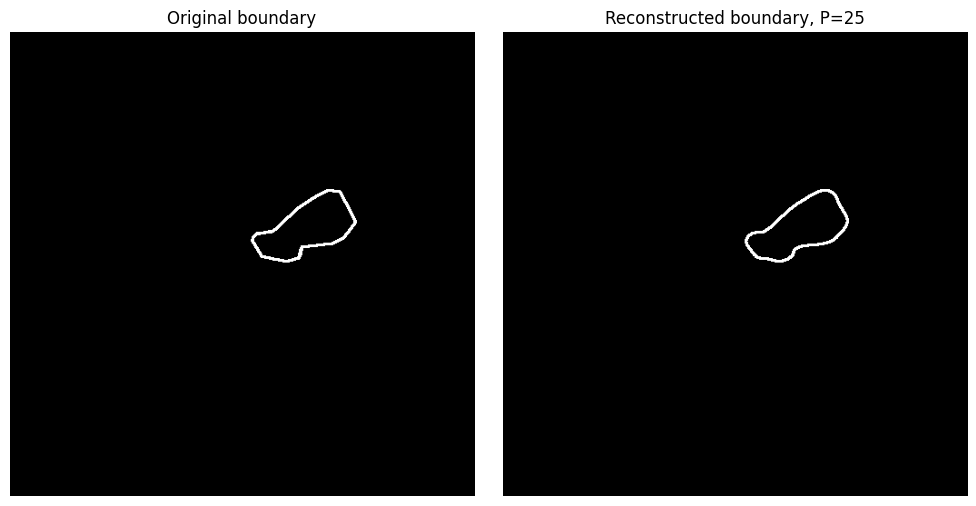

In [3]:
# test cell
boundary_points, fourier_descriptors, reconstructed_boundary, reconstructed_contour_image = (
    reconstruct_contour_by_fourier_descriptors(tumor_mask, p=25, line_width=2)
)

print(f"boundary points: {boundary_points.shape}, dtype: {boundary_points.dtype}")
print(f"fourier descriptors: {fourier_descriptors.shape}, dtype: {fourier_descriptors.dtype}")
print(f"reconstructed boundary: {reconstructed_boundary.shape}, dtype: {reconstructed_boundary.dtype}")

original_contour_image = contour_to_image(boundary_points, tumor_mask.shape, line_width=2)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_contour_image, cmap="gray")
axes[0].set_title("Original boundary")
axes[0].axis("off")
axes[1].imshow(reconstructed_contour_image, cmap="gray")
axes[1].set_title("Reconstructed boundary, P=25")
axes[1].axis("off")
plt.tight_layout()
plt.show()


### 1.2 Gradually increase the P value and observe the changes.

为了观察 Fourier descriptors 数量 P 对形状重建的影响，将原始边界和不同 P 值下的重建边界放在同一组图像中进行比较。


In [4]:
# function: show images in a row
def show_images_R1(
    images: list[NDArray[np.floating]],
    titles: list[str],
    cmap: str | None = "gray",
    vmin: float | None = None,
    vmax: float | None = None,
    figsize_per_image: tuple[float, float] = (3.0, 5.0),
) -> None:
    """Show images in one row."""
    fig, axes = plt.subplots(1, len(images), figsize=(len(images) * figsize_per_image[0], figsize_per_image[1]))
    axes = np.atleast_1d(axes)

    for ax, image, title in zip(axes, images, titles):
        if image.ndim == 2:
            ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
        else:
            ax.imshow(image)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# function: show images in multiple rows
def show_images_Rn(
    images: list[NDArray[np.floating]],
    titles: list[str],
    rows: int = 2,
    cols: int | None = None,
    cmap: str | None = "gray",
    vmin: float | None = None,
    vmax: float | None = None,
    figsize_per_image: tuple[float, float] = (3.0, 3.0),
) -> None:
    """Show images in a grid with fixed rows or columns."""
    if cols is None:
        cols = int(np.ceil(len(images) / rows))
    else:
        rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per_image[0], rows * figsize_per_image[1]))
    axes = np.atleast_1d(axes).ravel()

    for ax, image, title in zip(axes, images, titles):
        if image.ndim == 2:
            ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
        else:
            ax.imshow(image)
        ax.set_title(title)
        ax.axis("off")

    for ax in axes[len(images):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

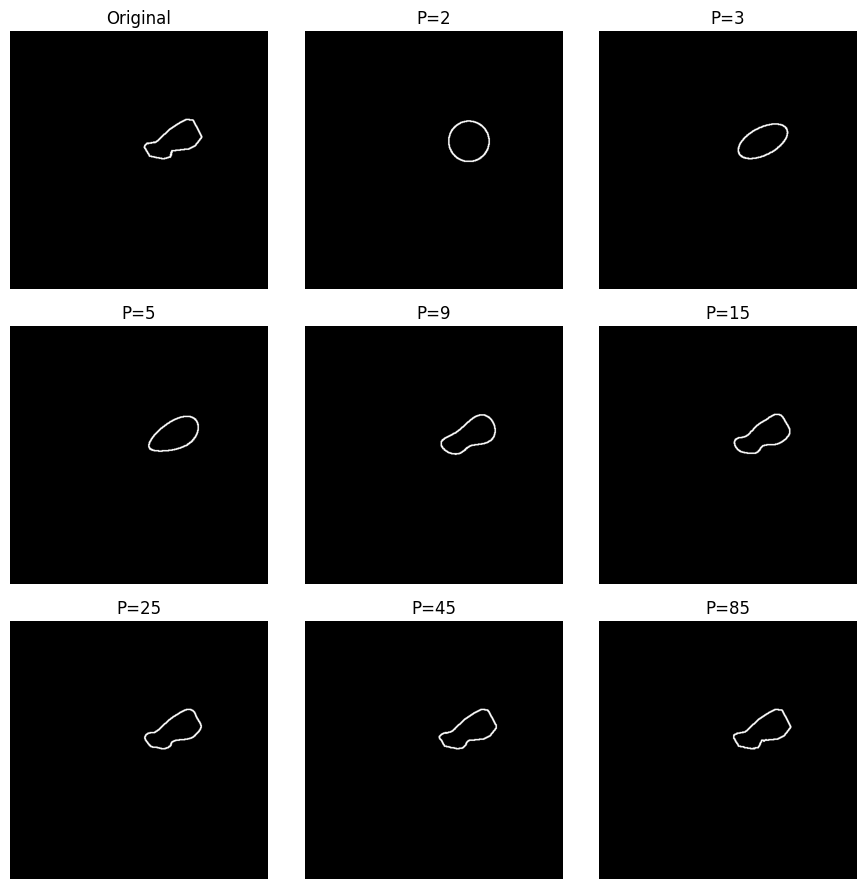

In [5]:
# test cell
p_values = [2, 3, 5, 9, 15, 25, 45, 85]
boundary_points = extract_boundary_points(tumor_mask)
comparison_images = [contour_to_image(boundary_points, tumor_mask.shape, line_width=2)]
comparison_titles = ["Original"]

for p in p_values:
    _, _, _, reconstructed_image = reconstruct_contour_by_fourier_descriptors(
        tumor_mask,
        p=p,
        line_width=2,
    )
    comparison_images.append(reconstructed_image)
    comparison_titles.append(f"P={p}")

show_images_Rn(comparison_images, comparison_titles, rows=3, cmap="gray", figsize_per_image=(3.0, 3.0))


可以看到，随着描述符 P 的增加，形状精度越来越高了。

### 1.3 边缘平滑程度量化

要量化 mask 的形状精度，可以通过量化 mask 的边缘平滑程度来实现。量化的方法为，对边缘进行 Fourier Transform，高频分量越多，边缘就约不平滑。

In [6]:
# function to calulate the edge smoothness
import pandas as pd


def calculate_edge_smoothness(
    contour_points: NDArray[np.floating],
) -> dict[str, float]:
    """Quantify edge smoothness by frequency-weighted Fourier energy."""
    centered_points = contour_points - contour_points.mean(axis=0)
    complex_contour = centered_points[:, 0] + 1j * centered_points[:, 1]
    descriptors = np.fft.fft(complex_contour)
    energy = np.abs(descriptors) ** 2
    energy[0] = 0

    num_points = contour_points.shape[0]
    frequency_indices = np.minimum(np.arange(num_points), num_points - np.arange(num_points))
    normalized_frequency = frequency_indices / frequency_indices.max()

    total_energy = energy.sum()
    weighted_high_frequency_energy = np.sum(normalized_frequency * energy) / total_energy if total_energy > 0 else 0.0
    smoothness = 1.0 - weighted_high_frequency_energy

    return {
        "WeightedHighFreqEnergy": float(weighted_high_frequency_energy),
        "Smoothness": float(smoothness),
    }


def summarize_smoothness_for_p_values(
    tumor_mask: NDArray[np.bool_],
    p_values: list[int],
) -> pd.DataFrame:
    """Calculate edge smoothness for original and Fourier-reconstructed contours."""
    boundary_points = extract_boundary_points(tumor_mask)
    fourier_descriptors = extract_fourier_descriptors(boundary_points)

    original_metrics = calculate_edge_smoothness(boundary_points)
    records = [{"P": "Original", **original_metrics}]

    for p in p_values:
        reconstructed_boundary = reconstruct_contour_from_descriptors(fourier_descriptors, p=p)
        smoothness_metrics = calculate_edge_smoothness(reconstructed_boundary)
        records.append({"P": p, **smoothness_metrics})

    smoothness_df = pd.DataFrame(records)
    roughness = smoothness_df["WeightedHighFreqEnergy"]
    roughness_min = roughness.min()
    roughness_max = roughness.max()
    if roughness_max == roughness_min:
        smoothness_df["ScaledSmoothness"] = 1.0
    else:
        normalized_roughness = (roughness - roughness_min) / (roughness_max - roughness_min)
        smoothness_df["ScaledSmoothness"] = 1.0 - 0.5 * normalized_roughness

    return smoothness_df


,P,WeightedHighFreqEnergy,Smoothness,ScaledSmoothness
0,Original,0.008562,0.991438,0.500000
1,2,0.007519,0.992481,1.000000
2,3,0.007519,0.992481,1.000000
3,5,0.007590,0.992410,0.965859
4,9,0.007809,0.992191,0.860850
5,15,0.007851,0.992149,0.840506
6,25,0.007870,0.992130,0.831754
7,45,0.007887,0.992113,0.823321
8,85,0.007957,0.992043,0.790029


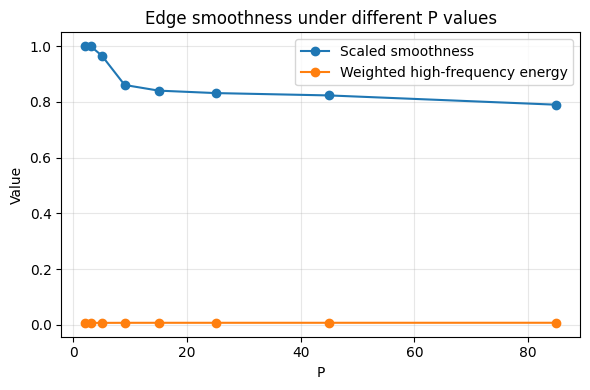

In [7]:
# test cell 
p_values_for_smoothness = [2, 3, 5, 9, 15, 25, 45, 85]
smoothness_table = summarize_smoothness_for_p_values(
    tumor_mask,
    p_values=p_values_for_smoothness,
)

display(smoothness_table)

plot_table = smoothness_table[smoothness_table["P"] != "Original"].copy()
plot_table["P"] = plot_table["P"].astype(int)

plt.figure(figsize=(6, 4))
plt.plot(plot_table["P"], plot_table["ScaledSmoothness"], marker="o", label="Scaled smoothness")
plt.plot(plot_table["P"], plot_table["WeightedHighFreqEnergy"], marker="o", label="Weighted high-frequency energy")
plt.xlabel("P")
plt.ylabel("Value")
plt.title("Edge smoothness under different P values")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


可以看到，随着 `P` 的增加，`Scaled smoothness` 会逐渐下降，也就是说边缘平滑程度会逐渐下降，也就是边缘细节越来越精细、形状精度越来越高。

## Project 2 First-Order Stats

### 2.1 Find the Center of mass of the tumor to get ROI

根据实验要求，先由 tumor mask 计算病灶质心，再根据病灶区域的 bounding box 确定 ROI 的长宽，最后以质心为中心截取病灶 ROI。


In [8]:
# functions to get ROI of tumor 

# get the center of mass of the tumor 
def get_tumor_center_of_mass(tumor_mask: NDArray[np.bool_]) -> tuple[int, int]:
    """Return the tumor center of mass as (row, col)."""
    rows, cols = np.nonzero(tumor_mask)
    if rows.size == 0:
        raise ValueError("tumor_mask does not contain tumor pixels.")

    center_row = int(np.rint(rows.mean()))
    center_col = int(np.rint(cols.mean()))
    return center_row, center_col


# get the limits of the bounding box of the tumor
def get_tumor_bounding_box(tumor_mask: NDArray[np.bool_]) -> tuple[int, int, int, int]:
    """Return tumor bounding box as (row_min, row_max, col_min, col_max)."""
    rows, cols = np.nonzero(tumor_mask)
    if rows.size == 0:
        raise ValueError("tumor_mask does not contain tumor pixels.")

    return int(rows.min()), int(rows.max() + 1), int(cols.min()), int(cols.max() + 1)


# use the center & limits to cut the ROI of the tumor 
def get_tumor_roi(
    mri_image: NDArray[np.integer],
    tumor_mask: NDArray[np.bool_],
    padding: int = 0,
) -> tuple[NDArray[np.integer], tuple[int, int], tuple[int, int, int, int]]:
    """Cut tumor ROI centered at tumor mass center with tumor bounding-box size."""
    center_row, center_col = get_tumor_center_of_mass(tumor_mask)
    row_min, row_max, col_min, col_max = get_tumor_bounding_box(tumor_mask)

    roi_height = row_max - row_min + 2 * padding
    roi_width = col_max - col_min + 2 * padding
    half_height = roi_height // 2
    half_width = roi_width // 2

    roi_row_min = max(0, center_row - half_height)
    roi_row_max = min(mri_image.shape[0], roi_row_min + roi_height)
    roi_col_min = max(0, center_col - half_width)
    roi_col_max = min(mri_image.shape[1], roi_col_min + roi_width)

    roi_row_min = max(0, roi_row_max - roi_height)
    roi_col_min = max(0, roi_col_max - roi_width)

    tumor_roi = mri_image[roi_row_min:roi_row_max, roi_col_min:roi_col_max]
    roi_box = (roi_row_min, roi_row_max, roi_col_min, roi_col_max)
    return tumor_roi, (center_row, center_col), roi_box


tumor center of mass (row, col): (216, 328)
tumor ROI box (row_min, row_max, col_min, col_max): (178, 255, 272, 385)
tumor ROI shape: (77, 113), dtype: int16


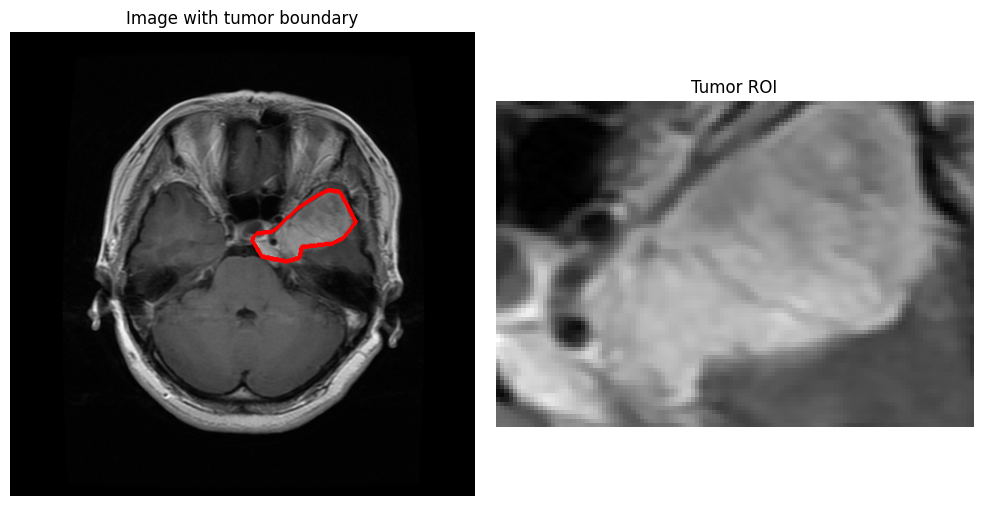

In [9]:
# test cell
tumor_ROI, tumor_center, tumor_roi_box = get_tumor_roi(mri_image, tumor_mask, padding=0)

print(f"tumor center of mass (row, col): {tumor_center}")
print(f"tumor ROI box (row_min, row_max, col_min, col_max): {tumor_roi_box}")
print(f"tumor ROI shape: {tumor_ROI.shape}, dtype: {tumor_ROI.dtype}")

show_images_R1(
    [image_with_tumor_boundary, tumor_ROI],
    ["Image with tumor boundary", "Tumor ROI"],
    cmap="gray",
    figsize_per_image=(5.0, 5.0),
)


为了便于后续直方图统计，将截取出的 ROI 先归一化，再按需要反相，并通过线性灰度映射将其压缩到指定灰度范围。


In [10]:
# function to process the tumor roi 
def normalize_image(
    image: NDArray[np.integer | np.floating]
) -> NDArray[np.floating]:
    """Normalize image intensity to [0, 1]."""
    image = image.astype(float)
    image_min = image.min()
    image_max = image.max()
    if image_max == image_min:
        return np.zeros_like(image, dtype=float)
    return (image - image_min) / (image_max - image_min)


def process_tumor_roi(
    tumor_roi: NDArray[np.integer | np.floating],
    lower_gray: float = 0.25,
    upper_gray: float = 0.75,
    invert: bool = True,
) -> tuple[
    NDArray[np.floating], 
    NDArray[np.floating], 
    NDArray[np.floating]
    ]:
    """Map tumor ROI intensities linearly to [lower_gray, upper_gray]."""
    normalized_roi = normalize_image(tumor_roi)
    input_roi = 1.0 - normalized_roi if invert else normalized_roi
    transformed_roi = lower_gray + (upper_gray - lower_gray) * input_roi
    return normalized_roi, input_roi, transformed_roi


normalized tumor ROI range: [0.0000, 1.0000]
inverted tumor ROI range: [0.0000, 1.0000]
processed tumor ROI range: [0.1500, 0.7500]


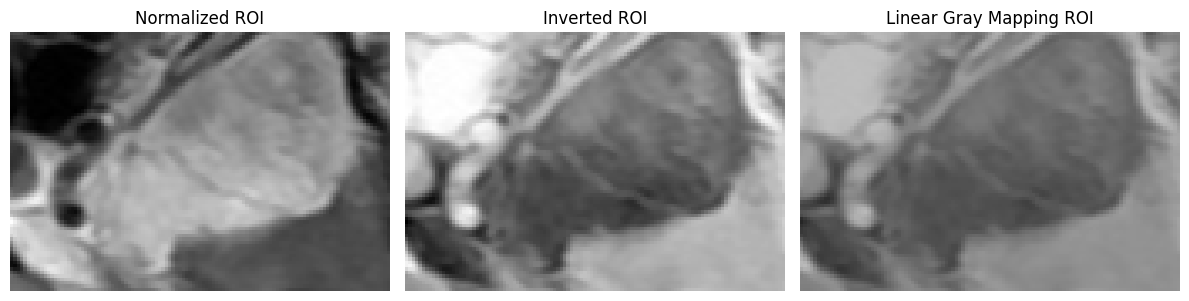

In [11]:
# test cell
normalized_tumor_ROI, inverted_tumor_ROI, processed_tumor_ROI = process_tumor_roi(
    tumor_ROI,
    lower_gray=0.15,
    upper_gray=0.75,
    invert=True,
)

print(f"normalized tumor ROI range: [{normalized_tumor_ROI.min():.4f}, {normalized_tumor_ROI.max():.4f}]")
print(f"inverted tumor ROI range: [{inverted_tumor_ROI.min():.4f}, {inverted_tumor_ROI.max():.4f}]")
print(f"processed tumor ROI range: [{processed_tumor_ROI.min():.4f}, {processed_tumor_ROI.max():.4f}]")

show_images_R1(
    [normalized_tumor_ROI, inverted_tumor_ROI, processed_tumor_ROI],
    ["Normalized ROI", "Inverted ROI", "Linear Gray Mapping ROI"],
    cmap="gray",
    vmin=0,
    vmax=1,
    figsize_per_image=(4.0, 4.0),
)


### 2.2 Implement first-order histogram features calculation: Mean, Variance, Uniformity, and Entropy.

分别实现计算直方图平均值、方差、均匀性 & 熵的函数。

In [12]:
# function to calculate histogram probabilities in the tumor ROI
def calculate_histogram_probabilities(
    image: NDArray[np.integer | np.floating],
    bins: int = 256,
    value_range: tuple[float, float] = (0.0, 1.0),
) -> tuple[NDArray[np.floating], NDArray[np.floating]]:
    """Calculate normalized histogram probabilities and bin centers."""
    hist, bin_edges = np.histogram(image.ravel(), bins=bins, range=value_range)
    probabilities = hist.astype(float) / hist.sum()
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    return probabilities, bin_centers


# function to calculate mean of histogram values in the tumor ROI
def calculate_histogram_mean(
    probabilities: NDArray[np.floating],
    gray_values: NDArray[np.floating],
) -> float:
    """Calculate first-order histogram mean."""
    return float(np.sum(gray_values * probabilities))


# function to calculate variance of histogram values in the tumor ROI
def calculate_histogram_variance(
    probabilities: NDArray[np.floating],
    gray_values: NDArray[np.floating],
    mean: float,
) -> float:
    """Calculate first-order histogram variance."""
    return float(np.sum(((gray_values - mean) ** 2) * probabilities))


# function to calculate uniformity of histogram values in the tumor ROI
def calculate_histogram_uniformity(probabilities: NDArray[np.floating]) -> float:
    """Calculate first-order histogram uniformity."""
    return float(np.sum(probabilities ** 2))


# function to calculate entropy of histogram values in the tumor ROI
def calculate_histogram_entropy(probabilities: NDArray[np.floating]) -> float:
    """Calculate first-order histogram entropy."""
    nonzero_probabilities = probabilities[probabilities > 0]
    return float(-np.sum(nonzero_probabilities * np.log2(nonzero_probabilities)))


def calculate_first_order_features(
    image: NDArray[np.integer | np.floating],
    bins: int = 256,
    value_range: tuple[float, float] = (0.0, 1.0),
) -> dict[str, float]:
    """Calculate mean, variance, uniformity, and entropy from image histogram."""
    probabilities, gray_values = calculate_histogram_probabilities(image, bins=bins, value_range=value_range)
    mean = calculate_histogram_mean(probabilities, gray_values)
    variance = calculate_histogram_variance(probabilities, gray_values, mean)
    uniformity = calculate_histogram_uniformity(probabilities)
    entropy = calculate_histogram_entropy(probabilities)

    return {
        "Mean": mean,
        "Variance": variance,
        "Uniformity": uniformity,
        "Entropy": entropy,
    }


In [13]:
# test cell 
first_order_features = calculate_first_order_features(
    processed_tumor_ROI,
    bins=256,
    value_range=(0.0, 1.0),
)

for feature_name, feature_value in first_order_features.items():
    print(f"{feature_name}: {feature_value:.6f}")


Mean: 0.479418
Variance: 0.015592
Uniformity: 0.010461
Entropy: 6.779486


### 2.3 Implement an iterative 3*3 mean filter to simulate an asymptotic Gaussian blurring.

实现一个能够迭代的滤波器，输入滤波核和迭代次数，自动迭代。

In [14]:
from scipy import ndimage

# function to apply a filter kernel repeatedly for a given number of iterations
# default iterations = 1
def iterative_filter(
    image: NDArray[np.integer | np.floating],
    kernel: NDArray[np.floating],
    iterations: int = 1,
    mode: str = "reflect",
) -> NDArray[np.floating]:
    """Apply a filter kernel repeatedly for a given number of iterations."""

    filtered_image = image.astype(float).copy()
    kernel = kernel.astype(float)

    for _ in range(iterations):
        filtered_image = ndimage.convolve(filtered_image, kernel, mode=mode)

    return filtered_image


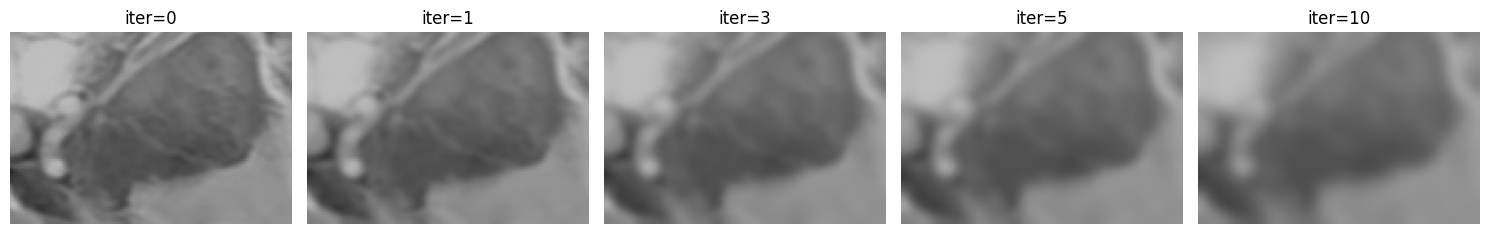

In [15]:
# test cell 
mean_kernel_3x3 = np.ones((3, 3), dtype=float) / 9
iter_list = [0, 1, 3, 5, 10]

filtered_tumor_ROI_list = [
    iterative_filter(processed_tumor_ROI, mean_kernel_3x3, iterations=iteration)
    for iteration in iter_list
]
filtered_titles = [f"iter={iteration}" for iteration in iter_list]

show_images_R1(
    filtered_tumor_ROI_list,
    filtered_titles,
    cmap="gray",
    vmin=0,
    vmax=1,
    figsize_per_image=(3.0, 3.0),
)


从结果上来看是有明显的模糊的。

### 2.4 Record the dynamic changes of statistical metrics during iterations.

可以用多种方式呈现指标的变化：表格 & 图像。表格用 dataframe 实现，图像呈现指标 - 迭代数关系图。

#### 2.4.1 表格呈现

表格比较简单，只需要一个整合数据的函数即可。将不同迭代后的指标整合到一个 dataframe 的表格中即可。

In [16]:
# function to record all metrics of the tumor ROI to a dataframe
import pandas as pd


def record_metrics_to_dataframe(
    images: list[NDArray[np.integer | np.floating]],
    iterations: list[int],
    bins: int = 256,
    value_range: tuple[float, float] = (0.0, 1.0),
) -> pd.DataFrame:
    """Record first-order histogram metrics of images into a dataframe."""
    if len(images) != len(iterations):
        raise ValueError("images and iterations must have the same length.")

    records = []
    for image, iteration in zip(images, iterations):
        metrics = calculate_first_order_features(image, bins=bins, value_range=value_range)
        metrics["Iteration"] = iteration
        records.append(metrics)

    metrics_df = pd.DataFrame(records)
    return metrics_df[["Iteration", "Mean", "Variance", "Uniformity", "Entropy"]]


In [17]:
# test cell 
metrics_table = record_metrics_to_dataframe(
    filtered_tumor_ROI_list,
    iter_list,
    bins=256,
    value_range=(0.0, 1.0),
)

metrics_table


,Iteration,Mean,Variance,Uniformity,Entropy
0,0,0.479418,0.015592,0.010461,6.779486
1,1,0.479415,0.014964,0.010830,6.743020
2,3,0.479438,0.014204,0.011185,6.695506
3,5,0.479420,0.013681,0.011325,6.673309
4,10,0.479439,0.012816,0.011632,6.639897


可以看到，随着迭代次数递增，图像各个参数变化如下：
- 均值：基本不变
- 方差：明显减小
- 均匀性：明显增大
- 熵：明显减小

#### 2.4.2 图像呈现

为了更连续地观察统计指标随滤波迭代次数的变化，逐次迭代均值滤波，并在每一次迭代后记录一阶统计量。


In [18]:
# function to get the metrics of the tumor ROI in every iteration
def record_metrics_during_iterations(
    image: NDArray[np.integer | np.floating],
    kernel: NDArray[np.floating],
    max_iterations: int,
    bins: int = 256,
    value_range: tuple[float, float] = (0.0, 1.0),
    mode: str = "reflect",
) -> pd.DataFrame:
    """Apply iterative filtering and record metrics after every iteration."""
    if max_iterations < 0:
        raise ValueError("max_iterations must be non-negative.")

    current_image = image.astype(float).copy()
    kernel = kernel.astype(float)
    records = []

    for iteration in range(max_iterations + 1):
        metrics = calculate_first_order_features(current_image, bins=bins, value_range=value_range)
        metrics["Iteration"] = iteration
        records.append(metrics)

        if iteration < max_iterations:
            current_image = ndimage.convolve(current_image, kernel, mode=mode)

    metrics_df = pd.DataFrame(records)
    return metrics_df[["Iteration", "Mean", "Variance", "Uniformity", "Entropy"]]


# plot the image to show the change of the tumor ROI in every iteration
def plot_metrics_during_iterations(
    metrics_df: pd.DataFrame
) -> None:
    """Plot first-order histogram metrics against iteration number."""
    metric_names = ["Mean", "Variance", "Uniformity", "Entropy"]
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    axes = axes.ravel()

    for ax, metric_name in zip(axes, metric_names):
        ax.plot(metrics_df["Iteration"], metrics_df[metric_name], marker="o", linewidth=1.8)
        ax.set_title(metric_name)
        ax.set_xlabel("Iteration")
        ax.set_ylabel(metric_name)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


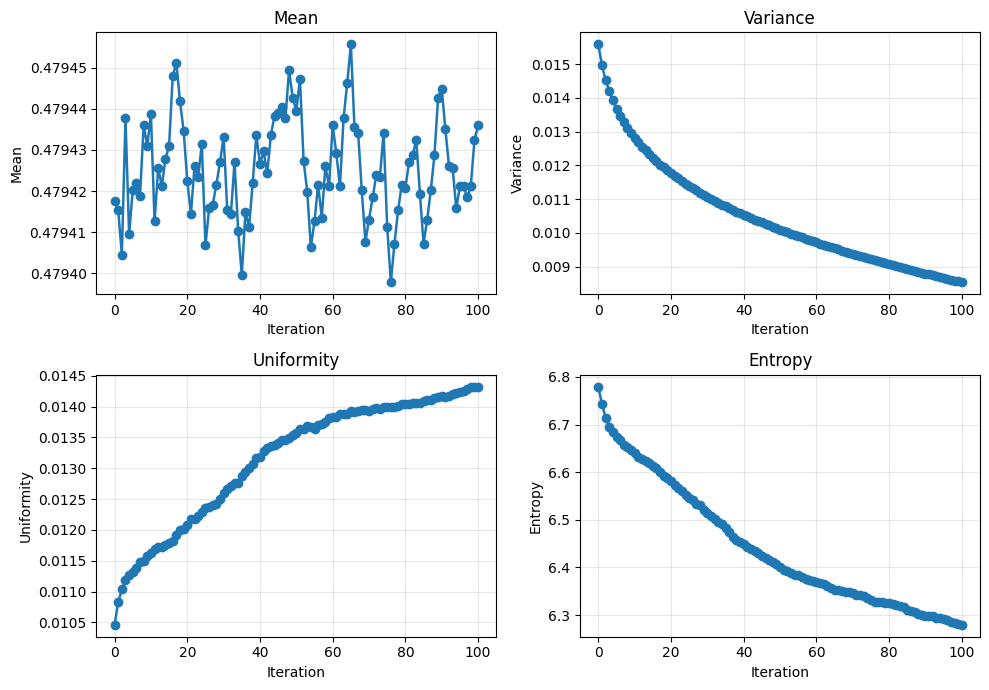

In [19]:
# test cell 
metrics_during_iterations = record_metrics_during_iterations(
    processed_tumor_ROI,
    mean_kernel_3x3,
    max_iterations=100,
    bins=256,
    value_range=(0.0, 1.0),
)

plot_metrics_during_iterations(metrics_during_iterations)


#### 2.4.3 对整张图进行重复

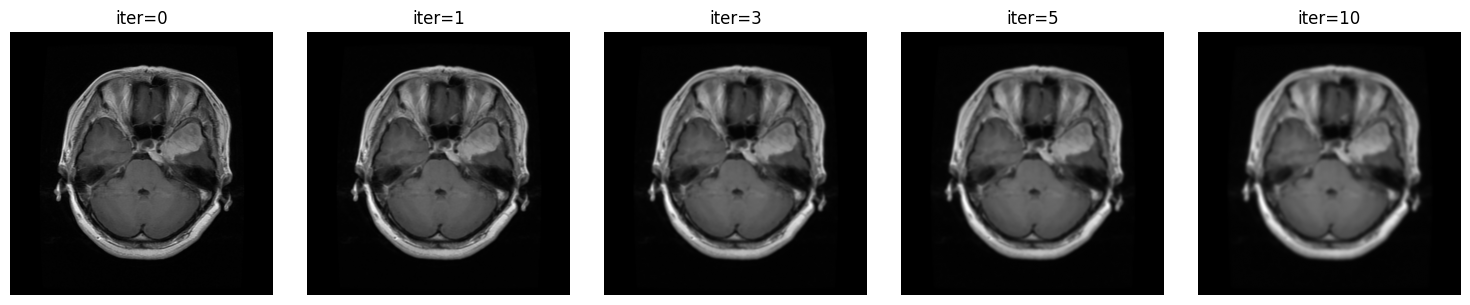

   Iteration      Mean  Variance  Uniformity   Entropy
0          0  0.131696  0.033475    0.108466  5.169083
1          1  0.131678  0.032739    0.110561  5.131213
2          3  0.131653  0.031865    0.109949  5.132306
3          5  0.131641  0.031263    0.109081  5.139727
4         10  0.131621  0.030190    0.107207  5.156408


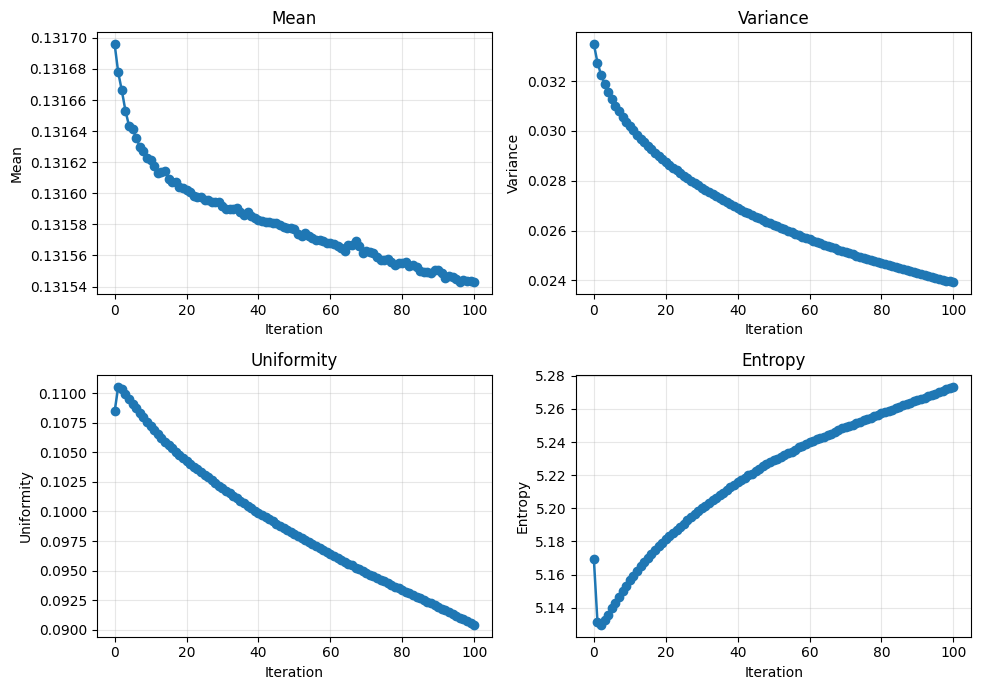

In [20]:
normalize_mri_image = normalize_image(mri_image)
mean_kernel_3x3 = np.ones((3, 3), dtype=float) / 9
iter_list = [0, 1, 3, 5, 10]

filtered_mri_image_list = [
    iterative_filter(normalize_mri_image, mean_kernel_3x3, iterations=iteration)
    for iteration in iter_list
]
filtered_titles = [f"iter={iteration}" for iteration in iter_list]


# show the change of the whole MRI image in every iteration
show_images_R1(
    filtered_mri_image_list,
    filtered_titles,
    cmap="gray",
    figsize_per_image=(3.0, 3.0),
)


# record the metrics of the whole MRI image in every iteration
metrics_table = record_metrics_to_dataframe(
    filtered_mri_image_list,
    iter_list,
    bins=256,
    value_range=(0.0, 1.0),
)

print(metrics_table)


# plot the change of the metrics of the whole MRI image in every iteration
metrics_during_iterations_image = record_metrics_during_iterations(
    normalize_mri_image,
    mean_kernel_3x3,
    max_iterations=100,
    bins=256,
    value_range=(0.0, 1.0),
)

plot_metrics_during_iterations(metrics_during_iterations_image)

可以看到，对全图进行相同的操作，各个指标的变化与之前的病灶区域并不完全相同。

- 均值：都基本保持不变。这是因为均值滤波本质上是局部平均操作，在整体灰度尺度上不会显著改变图像的平均强度。

- 方差：都随着迭代次数增加而下降。均值滤波会削弱局部灰度差异，使图像变得更加平滑，因此灰度方差减小。

- 均匀性：病灶的均匀性上升，但是全图的均匀性随着迭代次数增加反而会下降。在病灶中，滤波主要作用于肿瘤局部纹理和边界细节，因此图像均匀性上升，这个比较容易理解。但是在整幅图像中，除了病灶区域，还包含大量背景、正常脑组织以及组织边界，这导致全图的一致性在均值滤波后反而下降。

- 熵：病灶的熵会下降，全图的熵反而上升。这个现象的原因与均匀性差不多。在病灶中，随着迭代进行，均值滤波会让局部灰度变化被平滑，灰度分布变得更加集中，图像的熵会下降。但是在整幅图像中，由于存在大量背景、组织边界。均值滤波会使背景与组织边界附近的灰度扩散，产生更多中间灰度值，使全图直方图分布变得更分散。导致整张图片的熵反而增大。

以上均匀性和熵的反向变化，从某种角度反而说明了对病灶区域的 mask 是比较准确的。

## Project 3 Texture Feature & GLCM Analysis

### 3.1 Call functions to get second-order stats

In [21]:
import pandas as pd
from skimage.feature import graycomatrix, graycoprops


def quantize_image(
    image: NDArray[np.integer | np.floating],
    levels: int = 8,
) -> NDArray[np.integer]:
    """Quantize an image to integer gray levels in [0, levels - 1]."""
    normalized_image = normalize_image(image)
    quantized_image = np.floor(normalized_image * levels).astype(np.uint8)
    return np.clip(quantized_image, 0, levels - 1)


def calculate_second_order_stats(
    image: NDArray[np.integer | np.floating],
    levels: int = 8,
    distances: list[int] | None = [1],
    angles: list[float] | None = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4],
) -> tuple[pd.DataFrame, NDArray[np.integer]]:
    """Call library functions to calculate second-order texture statistics."""
    quantized_image = quantize_image(image, levels=levels)
    glcm = graycomatrix(
        quantized_image,
        distances=distances,
        angles=angles,
        levels=levels,
        symmetric=True,
        normed=True,
    )

    property_names = ["contrast", "dissimilarity", "homogeneity", "ASM", "energy", "correlation"]
    records = []
    for distance_index, distance in enumerate(distances):
        for angle_index, angle in enumerate(angles):
            record = {
                "Distance": distance,
                "Angle": angle,
            }
            for property_name in property_names:
                record[property_name] = float(graycoprops(glcm, property_name)[distance_index, angle_index])
            records.append(record)

    return pd.DataFrame(records), quantized_image

quantized tumor ROI shape: (77, 113), levels: 0-63


,Distance,Angle,contrast,dissimilarity,homogeneity,ASM,energy,correlation
0,1,0.000000,6.021220,1.524235,0.537575,0.005856,0.076527,0.982959
1,1,0.785398,12.448073,2.209352,0.456812,0.004534,0.067337,0.964907
2,1,1.570796,7.090009,1.678738,0.515718,0.005347,0.073124,0.980113
3,1,2.356194,12.020912,2.153900,0.451781,0.004469,0.066850,0.966109


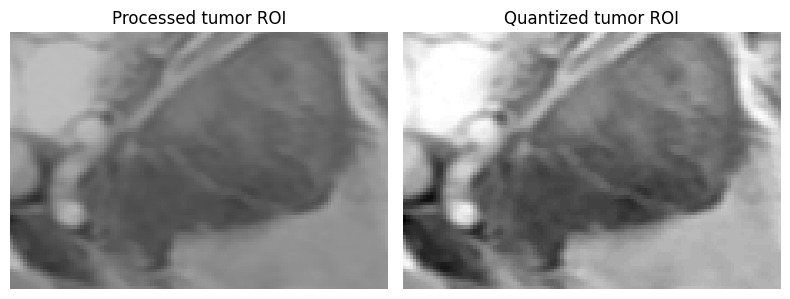

In [22]:
# test cell
second_order_stats_table, quantized_tumor_ROI = calculate_second_order_stats(
    processed_tumor_ROI,
    levels=64,
    distances=[1],
    angles=[0, np.pi / 4, np.pi / 2, 3 * np.pi / 4],
)

print(f"quantized tumor ROI shape: {quantized_tumor_ROI.shape}, levels: {quantized_tumor_ROI.min()}-{quantized_tumor_ROI.max()}")
display(second_order_stats_table)


show_images_R1(
    [processed_tumor_ROI, normalize_image(quantized_tumor_ROI)],
    ["Processed tumor ROI", "Quantized tumor ROI"],
    cmap="gray",
    vmin=0,
    vmax=1,
    figsize_per_image=(4.0, 4.0),
)

调用了 `skimage.feature` 中的 `graycomatrix`, `graycoprops` 两个已有函数，来计算灰度共生矩阵并借此获得二阶统计信息。

### 3.2 Compute the Gray-Level Co-occurrence Matrix (GLCM) based on specific spatial relationships.

先完成灰度共生矩阵的计算 & 展示函数。

GLCM 的计算需要考虑步长参数（距离参数），方便之后探究与周期性结构纹理的关系。

In [23]:
# function: calculate the GLCM
def calculate_glcm(
    quantized_image: NDArray[np.integer],
    levels: int,
    distance: int = 1,
    angle: float = 0,
    symmetric: bool = True,
    normalized: bool = True,
) -> NDArray[np.floating]:
    """Calculate GLCM manually for a specific spatial relationship."""
    if distance < 1:
        raise ValueError("distance must be at least 1.")

    row_offset = int(round(distance * np.sin(angle)))
    col_offset = int(round(distance * np.cos(angle)))
    height, width = quantized_image.shape
    glcm = np.zeros((levels, levels), dtype=float)

    for row in range(height):
        neighbor_row = row + row_offset
        if neighbor_row < 0 or neighbor_row >= height:
            continue

        for col in range(width):
            neighbor_col = col + col_offset
            if neighbor_col < 0 or neighbor_col >= width:
                continue

            current_gray = int(quantized_image[row, col])
            neighbor_gray = int(quantized_image[neighbor_row, neighbor_col])
            glcm[current_gray, neighbor_gray] += 1
            if symmetric:
                glcm[neighbor_gray, current_gray] += 1

    if normalized and glcm.sum() > 0:
        glcm = glcm / glcm.sum()

    return glcm


def calculate_glcm_set(
    quantized_image: NDArray[np.integer],
    levels: int,
    distances: list[int],
    angles: list[float],
    symmetric: bool = True,
    normalized: bool = True,
) -> dict[tuple[int, float], NDArray[np.floating]]:
    """Calculate GLCMs for multiple distances and angles."""
    glcm_dict = {}
    for distance in distances:
        for angle in angles:
            glcm_dict[(distance, angle)] = calculate_glcm(
                quantized_image,
                levels=levels,
                distance=distance,
                angle=angle,
                symmetric=symmetric,
                normalized=normalized,
            )
    return glcm_dict


# function: show the GLCM
def show_glcm(
    glcm: NDArray[np.floating],
    title: str = "GLCM",
    cmap: str = "viridis",
) -> None:
    """Show one GLCM as a heatmap."""
    plt.figure(figsize=(5, 4))
    plt.imshow(glcm, cmap=cmap)
    plt.title(title)
    plt.xlabel("Neighbor gray level")
    plt.ylabel("Current gray level")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def show_glcm_set(
    glcm_dict: dict[tuple[int, float], NDArray[np.floating]],
    cmap: str = "viridis",
    cols: int = 4,
) -> None:
    """Convert a GLCM dictionary to image lists and show them in a grid."""

    glcm_images = []
    glcm_titles = []
    for (distance, angle), glcm in glcm_dict.items():
        glcm_images.append(glcm)
        glcm_titles.append(f"d={distance}, angle={angle:.2f}")

    show_images_Rn(
        glcm_images,
        glcm_titles,
        cols=cols,
        cmap=cmap,
        vmin=0,
        vmax=max(float(glcm.max()) for glcm in glcm_images),
        figsize_per_image=(3.0, 3.0),
    )



=== Distance: 1 ===
distance=1, angle=0.00, shape=(64, 64), sum=1.0000
distance=1, angle=0.79, shape=(64, 64), sum=1.0000
distance=1, angle=1.57, shape=(64, 64), sum=1.0000
distance=1, angle=2.36, shape=(64, 64), sum=1.0000


=== Distance: 5 ===
distance=5, angle=0.00, shape=(64, 64), sum=1.0000
distance=5, angle=0.79, shape=(64, 64), sum=1.0000
distance=5, angle=1.57, shape=(64, 64), sum=1.0000
distance=5, angle=2.36, shape=(64, 64), sum=1.0000


=== Distance: 10 ===
distance=10, angle=0.00, shape=(64, 64), sum=1.0000
distance=10, angle=0.79, shape=(64, 64), sum=1.0000
distance=10, angle=1.57, shape=(64, 64), sum=1.0000
distance=10, angle=2.36, shape=(64, 64), sum=1.0000


=== Distance: 20 ===
distance=20, angle=0.00, shape=(64, 64), sum=1.0000
distance=20, angle=0.79, shape=(64, 64), sum=1.0000
distance=20, angle=1.57, shape=(64, 64), sum=1.0000
distance=20, angle=2.36, shape=(64, 64), sum=1.0000


=== Distance: 50 ===
distance=50, angle=0.00, shape=(64, 64), sum=1.0000
distance=50

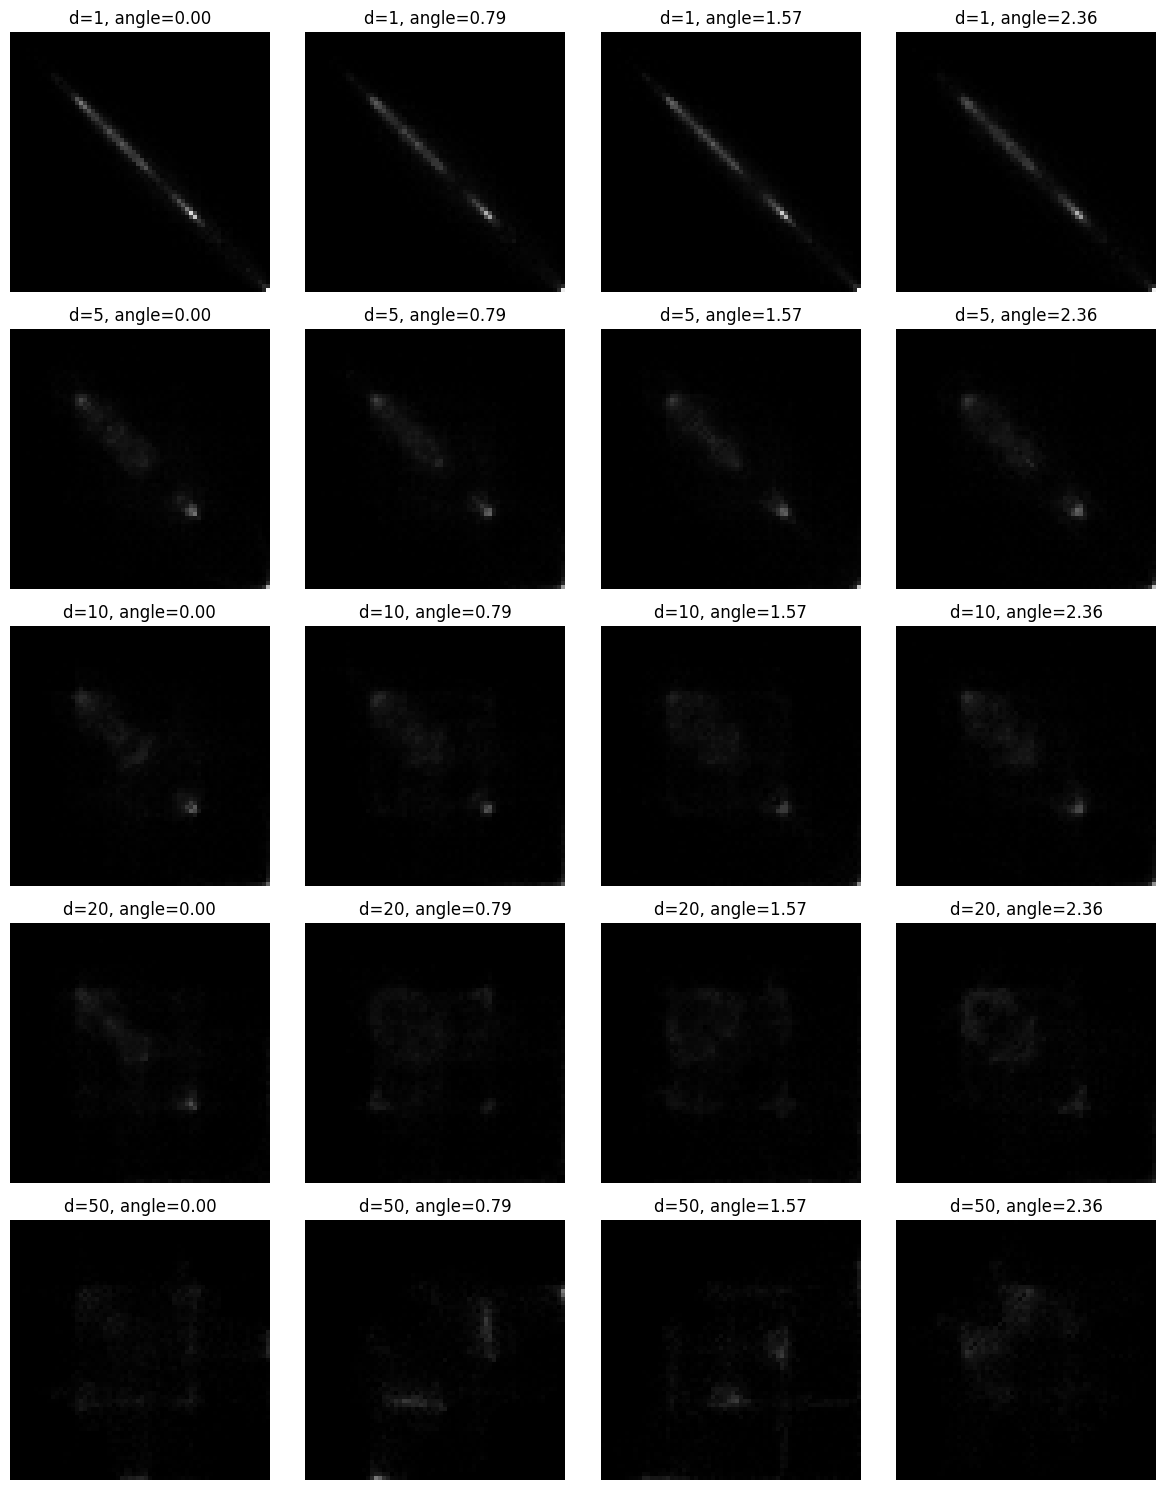

In [24]:
# test cell 
glcm_distance = [1, 5, 10, 20, 50]
glcm_angles = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
manual_glcm_dict = calculate_glcm_set(
    quantized_tumor_ROI,
    levels=64,
    distances=glcm_distance,
    angles=glcm_angles,
    symmetric=True,
    normalized=True,
)

current_distance = 0
for (distance, angle), glcm in manual_glcm_dict.items():
    if (current_distance != distance):
        print(f"\n\n=== Distance: {distance} ===")
        current_distance = distance
    print(f"distance={distance}, angle={angle:.2f}, shape={glcm.shape}, sum={glcm.sum():.4f}")

show_glcm_set(manual_glcm_dict, cmap="gray", cols=len(glcm_angles))


病灶 ROI 的周期性结构并不明显，因此仅从真实病灶的 GLCM 中较难直观看出采样步长与周期性纹理之间的关系。为了更清晰地展示该关系，下面构造一张具有明确周期的纹理图像进行分析。


### 3.3 生成特定参数的周期性纹理

In [25]:
# function to generate periodic textures with specific parameters
# parameters: distance, angle
def generate_periodic_texture(
    image_shape: tuple[int, int] = (128, 128),
    distance: int = 8,
    angle: float = 0,
    levels: int = 8,
) -> NDArray[np.integer]:
    """Generate a quantized periodic stripe texture."""
    if distance < 1:
        raise ValueError("distance must be at least 1.")
    if levels < 2:
        raise ValueError("levels must be at least 2.")

    rows, cols = np.indices(image_shape)
    projected_position = cols * np.cos(angle) + rows * np.sin(angle)
    sinusoid = 0.5 + 0.5 * np.sin(2 * np.pi * projected_position / distance)
    texture = np.floor(sinusoid * levels).astype(np.uint8)
    return np.clip(texture, 0, levels - 1)


def show_periodic_texture(
    texture: NDArray[np.integer],
    title: str = "Periodic texture",
    levels: int = 8,
) -> None:
    """Show a generated periodic texture."""
    show_images_R1(
        [texture],
        [title],
        cmap="gray",
        vmin=0,
        vmax=levels - 1,
        figsize_per_image=(4.0, 4.0),
    )


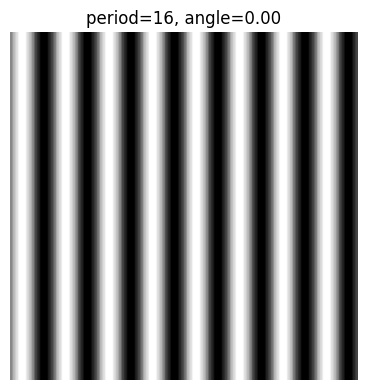

sampling step= 1, angle=0.00, trace=0.2520, max=0.1260
sampling step= 2, angle=0.00, trace=0.1270, max=0.0635
sampling step= 8, angle=0.00, trace=0.0250, max=0.1875
sampling step=16, angle=0.00, trace=0.9732, max=0.1875
sampling step=32, angle=0.00, trace=0.9792, max=0.1875
sampling step=64, angle=0.00, trace=0.9688, max=0.1875


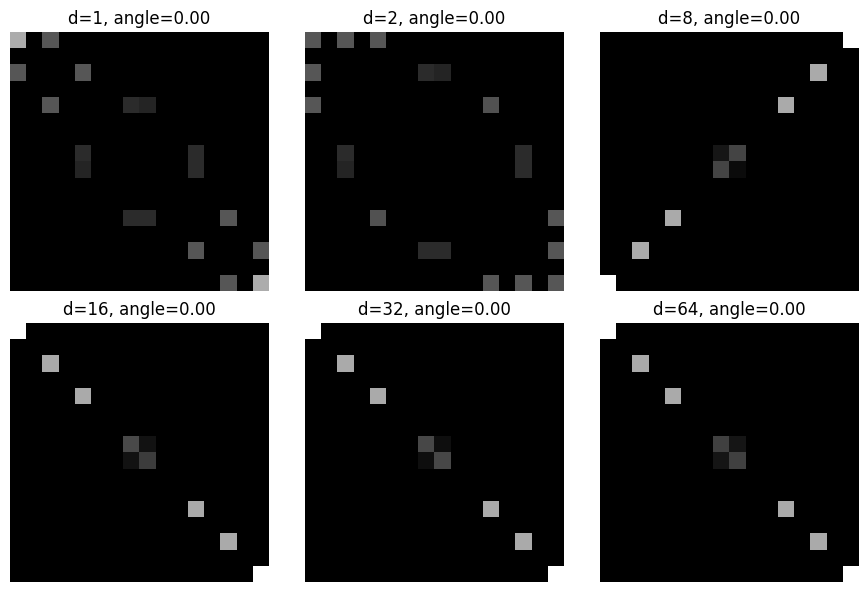

In [26]:
# calculate the GLCM of the generated texture and show it
texture_period = 16
texture_angle = 0
texture_levels = 16
periodic_texture = generate_periodic_texture(
    image_shape=(128, 128),
    distance=texture_period,
    angle=texture_angle,
    levels=texture_levels,
)

show_periodic_texture(
    periodic_texture,
    title=f"period={texture_period}, angle={texture_angle:.2f}",
    levels=texture_levels,
)

sampling_steps = [1, 2, 8, 16, 32, 64]
periodic_texture_glcm_dict = calculate_glcm_set(
    periodic_texture,
    levels=texture_levels,
    distances=sampling_steps,
    angles=[texture_angle],
    symmetric=True,
    normalized=True,
)

for (sampling_step, angle), glcm in periodic_texture_glcm_dict.items():
    diagonal_energy = float(np.trace(glcm))
    print(
        f"sampling step={sampling_step:2d}, angle={angle:.2f}, "
        f"trace={diagonal_energy:.4f}, max={glcm.max():.4f}"
    )

show_glcm_set(periodic_texture_glcm_dict, cmap="gray", cols=3)


用自己创建的有明显周期性的图像，就能够看出 GLCM 与周期性结构纹理的关系：

1. GLCM 对周期性纹理非常依赖采样步长 `distance`
2. 当采样步长与纹理周期匹配时，像素与其邻域像素更可能落在相同或相近的灰度等级，因此 GLCM 的能量会集中在对角线附近。
    - 当 `sampling step = 16, 32, 64`，也就是等于周期或周期整数倍时，大部分共现关系都集中在对角线上。
    - 当采样步长不是周期的整数倍时，GLCM 会呈现不同的分布。尤其是 `step = 8`，它正好是周期的一半，此时采样点往往落在相位相反或灰度差异较大的位置，也就是反对角线上。
3. GLCM 不仅反映纹理灰度共现关系，也会受到采样距离与纹理周期之间相位关系的显著影响。